# NBA Player Longevity Prediction – Feature Engineering

In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("nba-players.csv")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1340, 22)


,Unnamed: 0,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,3p,ftm,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,1.6,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,2.6,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,0.9,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,0.9,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,1.3,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


## Target Variable and Class Balance

In [ ]:
print(df['target_5yrs'].value_counts())
print()
print(df['target_5yrs'].value_counts(normalize=True))


target_5yrs
1    831
0    509
Name: count, dtype: int64

target_5yrs
1    0.620149
0    0.379851
Name: proportion, dtype: float64


The target variable is `target_5yrs`. Examining class balance helps determine whether the dataset is biased.

In [ ]:
target = df['target_5yrs']
drop_cols = [c for c in ['target_5yrs','name','Unnamed: 0'] if c in df.columns]
X = df.drop(columns=drop_cols)
print(X.columns.tolist())


['gp', 'min', 'pts', 'fgm', 'fga', 'fg', '3p_made', '3pa', '3p', 'ftm', 'fta', 'ft', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov']


## Correlation Heatmap and Multicollinearity

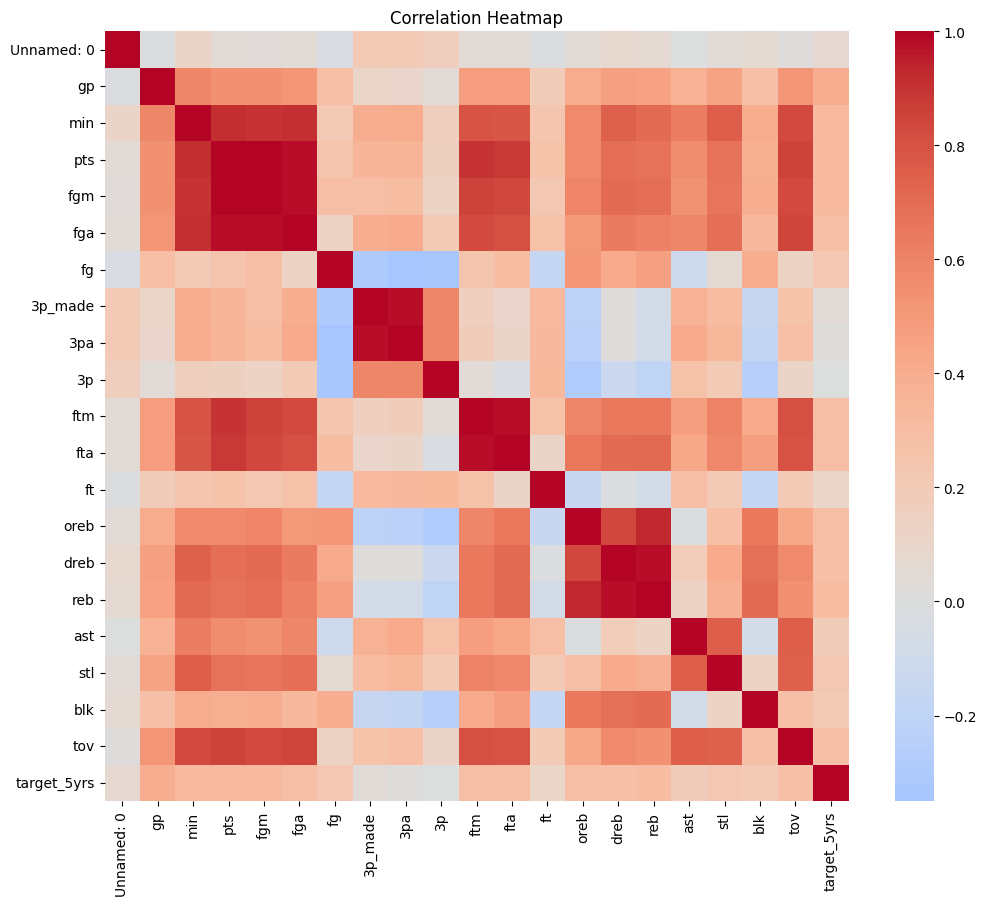

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.drop(columns=['name']).corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


In [ ]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    col for col in upper.columns if any(upper[col] > 0.90)
]

print("Highly correlated features:", high_corr_features)


Highly correlated features: ['pts', 'fgm', 'fga', '3pa', 'fta', 'reb']


Features with correlation above 0.90 were considered redundant and removed to reduce multicollinearity.

## Feature Engineering

In [ ]:
X['points_per_minute'] = X['pts']/(X['min']+1e-6)

X['efficiency_rating'] = (
    X['pts'] + X['reb'] + X['ast'] + X['stl'] + X['blk']
)/(X['gp']+1e-6)

X = X.drop(columns=high_corr_features)

X.head()


,gp,min,fg,3p_made,3p,ftm,ft,oreb,dreb,ast,stl,blk,tov,points_per_minute,efficiency_rating
0,36,27.4,34.7,0.5,25.0,1.6,69.9,0.7,3.4,1.9,0.4,0.4,1.3,0.270073,0.394444
1,35,26.9,29.6,0.7,23.5,2.6,76.5,0.5,2.0,3.7,1.1,0.5,1.6,0.267658,0.425714
2,74,15.3,42.2,0.4,24.4,0.9,67.0,0.5,1.7,1.0,0.5,0.3,1.0,0.339869,0.124324
3,58,11.6,42.6,0.1,22.6,0.9,68.9,1.0,0.9,0.8,0.6,0.1,1.0,0.491379,0.156897
4,48,11.5,52.4,0.0,0.0,1.3,67.4,1.0,1.5,0.3,0.3,0.4,0.8,0.391304,0.166667


In [ ]:
X = X.fillna(X.median(numeric_only=True))
print("Remaining missing values:", X.isnull().sum().sum())


Remaining missing values: 0


# Stakeholder Summary

- `target_5yrs` was selected as the dependent variable.
- Non-predictive columns were removed.
- Correlation analysis identified redundant features.
- Points Per Minute and Efficiency Rating were engineered to measure player productivity.
- Median imputation handled missing values.
- The dataset is now ready for machine learning models.
